# Milestone Project 1: Food Vision Big

## Check GPU

Google colab offeres free GPUs, however not all of them are compatible with mixed precision training.

Google Colab offeres:
* K80 (not compatible)
* P100 (not compatible)
* Tesla T4 (compatible)

In [1]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce GTX 1650 (UUID: GPU-f4cb0471-3cf4-3a88-76cc-3783fc94a541)


## Get helper function

In past modules, we've created a bunch of helper functions to do small tasks required for our notesbooks.
Rather than rewrite all of these, we can import a script and load them in from there.

In [2]:
# Import series of helper functions for the notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

## Use TensorFlow datasets to download data

In [3]:
# Get TensorFlow Datasets
import tensorflow_datasets as tfds

C:\Users\Priyesh\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# list all available datasets
datasets_list = tfds.list_builders() # Get all available datasets in TFDS
print("food101" in datasets_list)

True


In [5]:
# Load in the data (takes 5-6 minutes in Google colab)
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train", "validation"],
                                             shuffle_files=True,
                                             as_supervised=True, # data gets returned in tuple format (data, label)
                                             with_info=True)

## Exploring the Food101 data from TensorFlow datasets

In [6]:
# Features of Food1-1 from TFDS
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [7]:
# Get the class names
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [8]:
# Take one sample of the train data
train_one_sample = train_data.take(5) # Sample are in format (image_tensor, label)

In [9]:
# what does one sample of our training data look like?
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [10]:
# Output info about our training sample
for image, label in train_one_sample:
    print(f"""
          Image shape: {image.shape}
          Image datatype: {image.dtype}
          Target classfrom Food101 (tensor form): {label}
          Class name (str form): {class_names[label.numpy()]}
          """)


          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 90
          Class name (str form): spaghetti_bolognese
          

          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 3
          Class name (str form): beef_carpaccio
          

          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 93
          Class name (str form): steak
          

          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 79
          Class name (str form): prime_rib
          

          Image shape: (512, 512, 3)
          Image datatype: <dtype: 'uint8'>
          Target classfrom Food101 (tensor form): 79
          Class name (str form): prime_rib
          


In [11]:
# What does our image tensor from TFDS's Food101 look like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[225, 217, 198],
        [226, 218, 199],
        [230, 219, 199],
        ...,
        [239, 236, 229],
        [242, 242, 234],
        [246, 246, 238]],

       [[224, 216, 197],
        [226, 218, 199],
        [231, 220, 200],
        ...,
        [244, 241, 234],
        [240, 240, 232],
        [237, 237, 229]],

       [[224, 216, 197],
        [226, 218, 199],
        [231, 220, 200],
        ...,
        [239, 239, 231],
        [236, 236, 228],
        [232, 232, 224]],

       ...,

       [[207, 203, 191],
        [208, 204, 192],
        [211, 207, 195],
        ...,
        [238, 243, 236],
        [236, 241, 234],
        [234, 239, 232]],

       [[209, 207, 194],
        [209, 207, 194],
        [211, 209, 196],
        ...,
        [234, 239, 232],
        [233, 238, 231],
        [232, 237, 230]],

       [[209, 207, 194],
        [210, 208, 195],
        [210, 208, 195],
        ...,
        [228, 233, 22

In [12]:
# min and max values of in our image tensor
import tensorflow as tf
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image from TensorFlow datasets

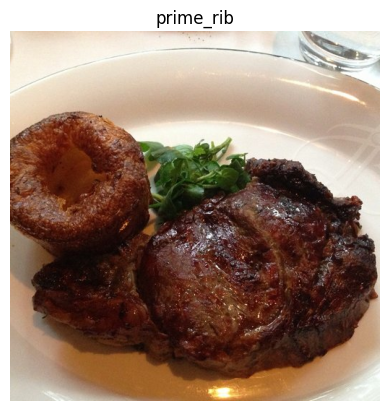

In [13]:
# Plot an image tensor
import matplotlib.pyplot as plt 
plt.imshow(image)
plt.title(class_names[label.numpy()]) # Add title to image to verify the label is associated with the right image 
plt.axis(False);

## Create preprocessing functions for our data

Neural networks perform best when data is in a certain way (e. g. batched, normalized, etc)

However, not all data (including data from TensorFlow datasets) comes like this.

So in order to get it ready for a neural network, you'll often have to write preprocessing functions and map it to your data.

What we know about our data:
* In `uint8` datatype
* Comprised of all different size tensors (different size images)
* Not scaled (the pixel values are between 0 & 255)

What we know models like:
* Data in `float32` dtype (or for mixed precision `float16` and `float32`)
* For batches, TensorFlow likes all of the tensors within a batch to be of the same size.
* Scaled (values between 0 & 1) also called normalized tensors generally perform better

With these points in mind, we've got a few things we can tackle with a preprocessing function.

Since we're going to be using an EfficientNetBX pretrained model from tf.keras.applicationss we don't need to rescale our data (these architecture have rescaling built-in).

This means our functions needs to :
1. Reshape our images to all the same size.
2. Convert the dtype of our image tensors from unit8 to float32

In [14]:
# Make a function for preprocessing images
def preprocess_img(image, label, img_shape=224):
    """
    Converts image datatype from 'unit8' -> 'float32' and reshapes image to [img_shape, colour_channells]
    """
    image = tf.image.resize(image, [img_shape, img_shape])
    return tf.cast(image, tf.float32), label

In [15]:
# Preprocess a single sample image and check the outputs
preprocessed_img = preprocess_img(image, label)[0]
print(f"Image before preprocessing:\n {image[:2]}..., \n Shape: {image.shape}, \nDatatype: {image.dtype} \n")
print(f"Image after preprocessing:\n{preprocessed_img[:2]}..., \nShape:{preprocessed_img.shape}, \nDatatype: {preprocessed_img.dtype}")

Image before preprocessing:
 [[[225 217 198]
  [226 218 199]
  [230 219 199]
  ...
  [239 236 229]
  [242 242 234]
  [246 246 238]]

 [[224 216 197]
  [226 218 199]
  [231 220 200]
  ...
  [244 241 234]
  [240 240 232]
  [237 237 229]]]..., 
 Shape: (512, 512, 3), 
Datatype: <dtype: 'uint8'> 

Image after preprocessing:
[[[225.41327 217.41327 198.41327]
  [231.57143 220.57143 198.71428]
  [235.06633 219.42346 196.20918]
  ...
  [233.63774 230.63774 223.20921]
  [239.16331 236.16331 229.16331]
  [240.53569 240.53569 232.53569]]

 [[225.28572 217.28572 198.28572]
  [233.71939 222.71939 202.58675]
  [234.68367 219.04082 195.82654]
  ...
  [242.40315 239.40315 231.97462]
  [233.22955 233.22955 225.22955]
  [232.58176 232.58176 224.58176]]]..., 
Shape:(224, 224, 3), 
Datatype: <dtype: 'float32'>


### Batch and prepare dataset

In [16]:
# Map preprocessing function to training (parallelize)
train_data = train_data.map(map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)

# Shuffle train data and turn it into batches and prefetch it (load it faster)
train_data = train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

# Map preprocessing function to test data
test_data = test_data.map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

In [17]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

## Create modelling callbacks

We're going to create a couple of callbacks to help us while our model trains:

* TensorBoard callback to log training results (so we can visualize them later if need be)
* ModelCheckpoint callback to save our model's progress after feature extraction

In [18]:
# Create tensorboard callback (import from helper_functions.py)
from helper_functions import create_tensorboard_callback

# Create ModelCheckpoint callback to save a model's progress during training
checkpoint_path = "model_checkpoints/cp.ckpt"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                      monitor="val_acc",
                                                      save_best_only=True,
                                                      save_weights_only=True,
                                                      verbose=0)

## Setup mixed precision training

In [19]:
# Turn on mixed precision training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


In [20]:
mixed_precision.global_policy()

<Policy "mixed_float16">

## Build feature extraction model

In [21]:
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing

# Create base model
input_shape = (224, 224, 3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Create functional model
inputs = layers.Input(shape=input_shape, name="input_layer")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(len(class_names))(x)
outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)
model = tf.keras.Model(inputs, outputs)

# Compile the model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [22]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, None, None, 1280   4049571   
 )                           )                                   
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 101)               129381    
                                                                 
 softmax_float32 (Activatio  (None, 101)               0         
 n)                                                              
                                                             

## Checking layer dtype policies (are we using mixed precision?)

In [24]:
# Check the dtype_policy atrtributes of layers in our model
for layer in model.layers:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer True float32 <Policy "float32">
efficientnetb0 False float32 <Policy "mixed_float16">
global_average_pooling2d True float32 <Policy "mixed_float16">
dense True float32 <Policy "mixed_float16">
softmax_float32 True float32 <Policy "float32">


In [28]:
# Check the dtype_policy attributes of layers in our model
for layer in model.layers[1].layers:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_1 False float32 <Policy "float32">
rescaling False float32 <Policy "mixed_float16">
normalization False float32 <Policy "mixed_float16">
rescaling_1 False float32 <Policy "mixed_float16">
stem_conv_pad False float32 <Policy "mixed_float16">
stem_conv False float32 <Policy "mixed_float16">
stem_bn False float32 <Policy "mixed_float16">
stem_activation False float32 <Policy "mixed_float16">
block1a_dwconv False float32 <Policy "mixed_float16">
block1a_bn False float32 <Policy "mixed_float16">
block1a_activation False float32 <Policy "mixed_float16">
block1a_se_squeeze False float32 <Policy "mixed_float16">
block1a_se_reshape False float32 <Policy "mixed_float16">
block1a_se_reduce False float32 <Policy "mixed_float16">
block1a_se_expand False float32 <Policy "mixed_float16">
block1a_se_excite False float32 <Policy "mixed_float16">
block1a_project_conv False float32 <Policy "mixed_float16">
block1a_project_bn False float32 <Policy "mixed_float16">
block2a_expand_conv False float32 <

## Fit the feature extraction model

If our goal is o fine-tune a pretrained model, the general order of doing things is:
1. Build a feature extraction model (train a couple output layers with base layers frozen)
2. Fine-tune some of the frozen layers

In [29]:
# Fit the feature extraction model with callbacks
history_101_food_classes_feature_extract = model.fit(train_data,
                                                     epochs=3,
                                                     steps_per_epoch=(len(train_data)),
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)),
                                                     callbacks=[create_tensorboard_callback(dir_name="training_logs",
                                                                                            experiment_name="efficientnetb0_101_classes_all_data_feature_extract"),
                                                                model_checkpoint]) 

Saving TensorBoard log files to: training_logs/efficientnetb0_101_classes_all_data_feature_extract/20240523-180804
Epoch 1/3



2368/2368 [==============================] - ETA: 0s - loss: nan - accuracy: 0.0099WARNING:tensorflow:Can save best model only with val_acc available, skipping.


2368/2368 [==============================] - 3923s 2s/step - loss: nan - accuracy: 0.0099 - val_loss: nan - val_accuracy: 0.0069
Epoch 2/3
2368/2368 [==============================] - ETA: 0s - loss: nan - accuracy: 0.0099WARNING:tensorflow:Can save best model only with val_acc available, skipping.


2368/2368 [==============================] - 3918s 2s/step - loss: nan - accuracy: 0.0099 - val_loss: nan - val_accuracy: 0.0072
Epoch 3/3
2368/2368 [==============================] - ETA: 0s - loss: nan - accuracy: 0.0099WARNING:tensorflow:Can save best model only with val_acc available, skipping.


2368/2368 [==============================] - 6684s 3s/step - loss: nan - accuracy: 0.0099 - val_loss: nan - val_accuracy: 0.0072


In [30]:
# Evaluate model on whole test dataset
results_feature_extract_model = model.evaluate(test_data)
results_feature_extract_model

790/790 [==============================] - 1245s 2s/step - loss: nan - accuracy: 0.0099


[nan, 0.009900989942252636]

In [32]:
model.save("history_101_food_classes_feature_extract")

INFO:tensorflow:Assets written to: history_101_food_classes_feature_extract\assets


INFO:tensorflow:Assets written to: history_101_food_classes_feature_extract\assets


In [3]:
import tensorflow as tf
model_1 = tf.keras.models.load_model("history_101_food_classes_feature_extract")



The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once



In [4]:
model_1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, None, None, 1280   4049571   
 )                           )                                   
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 101)               129381    
                                                                 
 softmax_float32 (Activatio  (None, 101)               0         
 n)                                                              
                                                             